### Assignment 1 Deep Learning and Sensor fusion 2026

Multi class Classification

### Necessary iomport here 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import Dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import os 
import numpy as np 
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split 

print(f"[INFO] Torch infos: {torch.__version__}")

DATASET_PATH = os.path.join("..", "Dataset", "BoneBreakClassification")

[INFO] Torch infos: 2.9.1+cu128


In [2]:
# some helpers
def load_data(dataset_path, class_names, type_of_data_to_load):
    # for each class name 
    images, labels = list(), list() 
    for el in class_names.keys():
        print(f"[WALKING] Walking into {el}")
        for images_name in os.listdir(os.path.join(dataset_path, el, type_of_data_to_load)):
            full_image_path = os.path.join(dataset_path, el, type_of_data_to_load, images_name)
            images.append(full_image_path)
            labels.append(class_names[el])
    return images, labels

# set Dataset path
The path yopu see in the code point to my folder 

```
.
├── Assignment_1
│   ├── Assignment_1_four_layers.ipynb
│   ├── Assignment_1_template.ipynb
│   ├── Assignment_1_three_layers.ipynb
│   └── cnn_ass_1.pt
├── Dataset
│   ├── BoneBreakClassification

```

If you put the data in a different place change it. 

In [3]:
DATASET_PATH = os.path.join("BoneBreakClassification")

### (1) Load dataset

In [4]:
class_names = dict()   

temp = os.listdir(DATASET_PATH)
temp = sorted(temp)

# prep up list and class number together
for i in range(len(temp)):
    class_names[temp[i]] = i

data_to_split, labels_to_split = load_data(dataset_path=DATASET_PATH,
                                                       class_names=class_names,
                                                       type_of_data_to_load="Train")

print(f"[DATA TO SPLIT] Data loaded complete {len(data_to_split)} Labeles are {len(labels_to_split)}")

# load test data 
test_data_handler, test_labels_handler = load_data(dataset_path=DATASET_PATH,
                                                   class_names=class_names,
                                                   type_of_data_to_load="Test")

print(f"[TRAIN DATA LOADED] Data loaded complete {len(test_data_handler)} Labeles are {len(test_labels_handler)}")


[WALKING] Walking into Avulsion fracture
[WALKING] Walking into Comminuted fracture
[WALKING] Walking into Fracture Dislocation
[WALKING] Walking into Greenstick fracture
[WALKING] Walking into Hairline Fracture
[WALKING] Walking into Impacted fracture
[WALKING] Walking into Longitudinal fracture
[WALKING] Walking into Oblique fracture
[WALKING] Walking into Pathological fracture
[WALKING] Walking into Spiral Fracture
[DATA TO SPLIT] Data loaded complete 989 Labeles are 989
[WALKING] Walking into Avulsion fracture
[WALKING] Walking into Comminuted fracture
[WALKING] Walking into Fracture Dislocation
[WALKING] Walking into Greenstick fracture
[WALKING] Walking into Hairline Fracture
[WALKING] Walking into Impacted fracture
[WALKING] Walking into Longitudinal fracture
[WALKING] Walking into Oblique fracture
[WALKING] Walking into Pathological fracture
[WALKING] Walking into Spiral Fracture
[TRAIN DATA LOADED] Data loaded complete 140 Labeles are 140


# (2) leave this cell because we need to create a val dataset and it is not there as default

In [5]:
# here you can split validation in stead of test so you can preserve intacted the test set. 
train_data_handler, validation_data_handler, train_labels_handler, validation_labels_handler = train_test_split(np.array(data_to_split), np.array(labels_to_split), test_size=0.20)

print(f"[TRAIN DATA] The train data is {train_data_handler.shape}  and its labels are {train_labels_handler.shape}")
print(f"[VALIDATION DATA] The validation data is {validation_data_handler.shape}  and its labels are {validation_labels_handler.shape}")

# my data loader need list yours? adapt it to your code
train_data_handler = list(train_data_handler)
train_labels_handler = list(train_labels_handler)

validation_data_handler = list(validation_data_handler)
validation_labels_handler = list(validation_labels_handler)

[TRAIN DATA] The train data is (791,)  and its labels are (791,)
[VALIDATION DATA] The validation data is (198,)  and its labels are (198,)


### (3) Here ate two transforms one for training and one for evaluation 

train transform need data augmentation:
- add random flip
- add random rotation
- add color jitter 

both need need:
- resize
- toTensor handler
- Normalize (use the provided MEAN and STD)

Note that the evaluation transform does not need data augmentation.

In [6]:
TARGET_H = 224
TARGET_W = 224
IMAGE_MEAN = [0.485,0.456,0.406]
IMAGE_STD = [0.229,0.224,0.225]

rotation_degree = 20
# create transform 
train_transform = transforms.Compose([
    transforms.Resize((TARGET_W,TARGET_H)),
    transforms.RandomVerticalFlip(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(rotation_degree),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGE_MEAN,IMAGE_STD)
])

evaluation_transform = transforms.Compose([
    transforms.Resize((TARGET_W,TARGET_H)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGE_MEAN,IMAGE_STD)
])

In [7]:
class MyDataset(Dataset):
    def __init__(self, list_of_pathes, list_of_classes, transform=None) -> None:
        super().__init__()
        self.list_of_pathes = list_of_pathes
        self.list_of_classes = list_of_classes
        self.transform = transform

    def __len__(self):
        return len(self.list_of_pathes)
    
    def __getitem__(self, index):
        path = self.list_of_pathes[index]
        label = self.list_of_classes[index]
        image = Image.open(path).convert("RGB")
        image_as_tensor= self.transform(image)
        # return image and label
        return image_as_tensor, label 

### (4) Create data loder from the MyDataset class 

In [8]:
train_dataset = MyDataset(list_of_pathes=train_data_handler,
                          list_of_classes=train_labels_handler,
                          transform=train_transform)

validation_dataset = MyDataset(list_of_pathes=validation_data_handler,
                                list_of_classes=validation_labels_handler,
                                transform=evaluation_transform)

test_dataset = MyDataset(list_of_pathes=test_data_handler,
                          list_of_classes=test_labels_handler,
                          transform=evaluation_transform)

# put those here
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True,num_workers= 0,pin_memory= True)
val_loader = DataLoader(validation_dataset,batch_size=128,shuffle=False, num_workers= 0,pin_memory= True)
test_loader = DataLoader(test_dataset,batch_size=128,shuffle=False, num_workers= 0,pin_memory= True)

### Instance of the CNN 
Use the Sequential API it is faster 
- This cnn has two hidden layers (conv2d -> proper activation -> max pool 2d)  one has 16 untis and the second has 32 units
- Add a flatten layer 
- Classifier need 128 Linear unit proper activation and set dropdown at 0.5
- The last layer of the classifier how many units need?


In [9]:
class MyCNN(nn.Module):
    def __init__(self, 
                 number_of_output_classes, 
                 kernel_size, 
                 padding_size, 
                 pooling_size, 
                 input_channels,
                 dropout_probabilities: float,
                 dense_units: list[int],
                 layers_list: list[int]
                 ):
        
        super().__init__()

        layers = []

        input_units = input_channels

        for output_units in layers_list:
            layers +=[
                nn.Conv2d(input_units,output_units,kernel_size=kernel_size,padding=padding_size),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(pooling_size)
            ]
            input_units = output_units
        
        self.features = nn.Sequential(*layers)

        mlp = []
        count_layer = 0
        for i in layers_list:
            count_layer +=1
        if count_layer == 2: 
            in_features = layers_list[-1]*56*56 # since maxpool 2 times
        else:
            in_features = layers_list[-1]*28*28 # since maxpool 3 times


        for h in dense_units:
            mlp += [
                nn.Linear(in_features,h),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout_probabilities)
            ]
            in_features = h

        self.classifier = nn.Sequential(*mlp)
        self.flatten_layer = nn.Flatten()
        self.final_classifier = nn.Linear(in_features,number_of_output_classes)

    def forward(self,x):
        x = self.features(x)
        x = self.flatten_layer(x)
        x = self.classifier(x)
        x = self.final_classifier(x)

        return x 

### (5) Add proper optimizer and loss function set training epochs to 50

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (f"Device is {device}")

Device is cuda


In [11]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0 
    total = 0
    
    for images, labels in loader :
        images,labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits,labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()*images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    train_loss = running_loss / total
    accuracy = correct / total
    return train_loss, accuracy

params = {
    "number_of_output_classes":10, 
    "kernel_size":3, 
    "padding_size":1, 
    "pooling_size":2, 
    "input_channels":3,
    "dropout_probabilities":0.5,
    "dense_units":[128],
    "layers_list":[16,32] 
}
model = MyCNN(**params)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr= 1e-3,weight_decay=1e-4)

In [12]:
@torch.no_grad()
def evaluation(model,loader,criterion,device):
    model.eval()
    correct,total = 0,0
    running_loss = 0.0
    
    for image, label in loader:
        image = image.to(device)
        label = label.to(device)
        
        logits = model(image)
        loss= criterion(logits,label)
        current__image_loss = loss.item()
        
        running_loss += current__image_loss*image.size(0)
        
        prediction = logits.argmax(dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)
        
    val_loss = running_loss / total
    val_accuracy = correct / total
    return val_loss, val_accuracy

# (6) add here the train and evaluation loop collect loss and accuracy, we want to see curves here 

In [13]:
epochs = 50
best_val_acc = 0
val_acc = 0
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range (1, epochs + 1):
    train_loss, train_acc = train(model = model,loader=train_loader, criterion=criterion, optimizer=optimizer, device=device)
    print(f"Epoch #{epoch}/{epochs}, Train Loss = {train_loss:.4f}, Accuracy = {train_acc:.3f}")  
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_loss, val_acc = evaluation(model = model,loader=val_loader, criterion=criterion, device=device)
    print(f"Epoch #{epoch}/{epochs}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_acc:.3f}")  
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if (val_acc > best_val_acc):
        best_val_acc = val_acc
        torch.save(model.state_dict(),"Assignment1_best_model_2layer.pt")
print("Best Val Accuracy", best_val_acc)

Epoch #1/50, Train Loss = 3.5739, Accuracy = 0.083
Epoch #1/50, Val Loss = 2.2992, Val Accuracy = 0.126
Epoch #2/50, Train Loss = 2.3032, Accuracy = 0.080
Epoch #2/50, Val Loss = 2.2999, Val Accuracy = 0.131
Epoch #3/50, Train Loss = 2.2985, Accuracy = 0.099
Epoch #3/50, Val Loss = 2.2955, Val Accuracy = 0.126
Epoch #4/50, Train Loss = 2.2911, Accuracy = 0.120
Epoch #4/50, Val Loss = 2.2849, Val Accuracy = 0.146
Epoch #5/50, Train Loss = 2.2797, Accuracy = 0.102
Epoch #5/50, Val Loss = 2.2811, Val Accuracy = 0.126
Epoch #6/50, Train Loss = 2.2637, Accuracy = 0.140
Epoch #6/50, Val Loss = 2.2718, Val Accuracy = 0.126
Epoch #7/50, Train Loss = 2.2682, Accuracy = 0.134
Epoch #7/50, Val Loss = 2.2657, Val Accuracy = 0.146
Epoch #8/50, Train Loss = 2.2638, Accuracy = 0.138
Epoch #8/50, Val Loss = 2.2609, Val Accuracy = 0.136
Epoch #9/50, Train Loss = 2.2551, Accuracy = 0.148
Epoch #9/50, Val Loss = 2.2587, Val Accuracy = 0.157
Epoch #10/50, Train Loss = 2.2565, Accuracy = 0.144
Epoch #10/50

In [14]:
model.load_state_dict(torch.load("Assignment1_best_model_2layer.pt"))
print(f"Loaded best model with validation accuracy: {best_val_acc:.4f}")

Loaded best model with validation accuracy: 0.2626


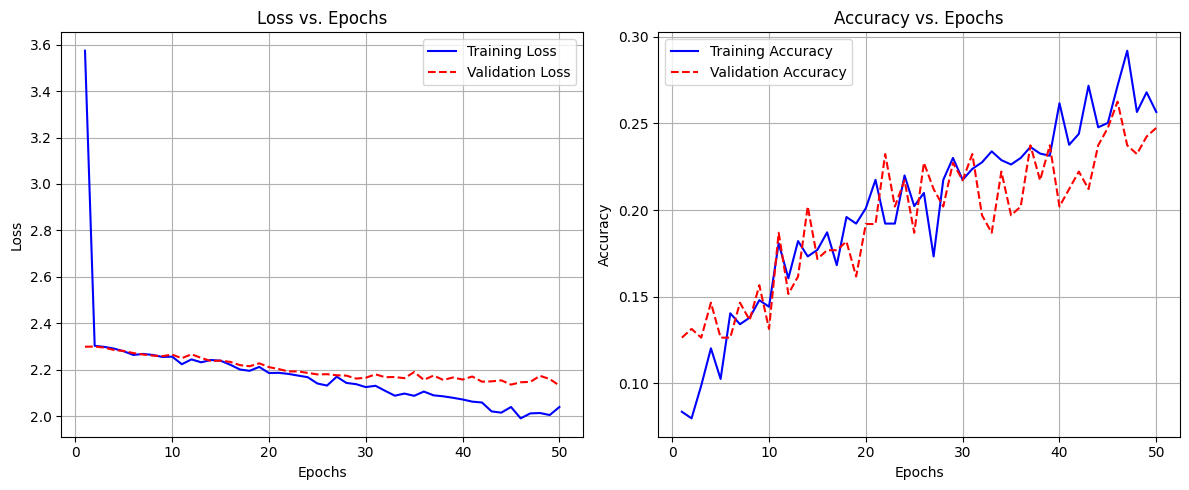

In [15]:
plt.figure(figsize=(12, 5))
# Plot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color='red', linestyle='--')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# Plot 2: Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_accs) + 1), val_accs, label='Validation Accuracy', color='red', linestyle='--')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# (7) Make prediction and shows some predicted images

In [16]:
def visualize_predictions(model, data_loader, device, num_images=8, figsize=(15, 10)):

    model.eval()
    images, labels = next(iter(data_loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        logits = model(images)
        probs = F.softmax(logits, dim=1)  
        predictions = torch.argmax(probs, dim=1)
    
    plt.figure(figsize=figsize)
    for i in range(num_images):
        plt.subplot(2, 4, i + 1)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        img = img * IMAGE_STD + IMAGE_MEAN  
        img = np.clip(img, 0, 1) 
        plt.imshow(img)
        
        gt = labels[i].item()
        pred = predictions[i].item()
        p_val = probs[i][pred].item()
        
        plt.title(f"GT:{gt} Pred:{pred}\nP:{p_val:.2f}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

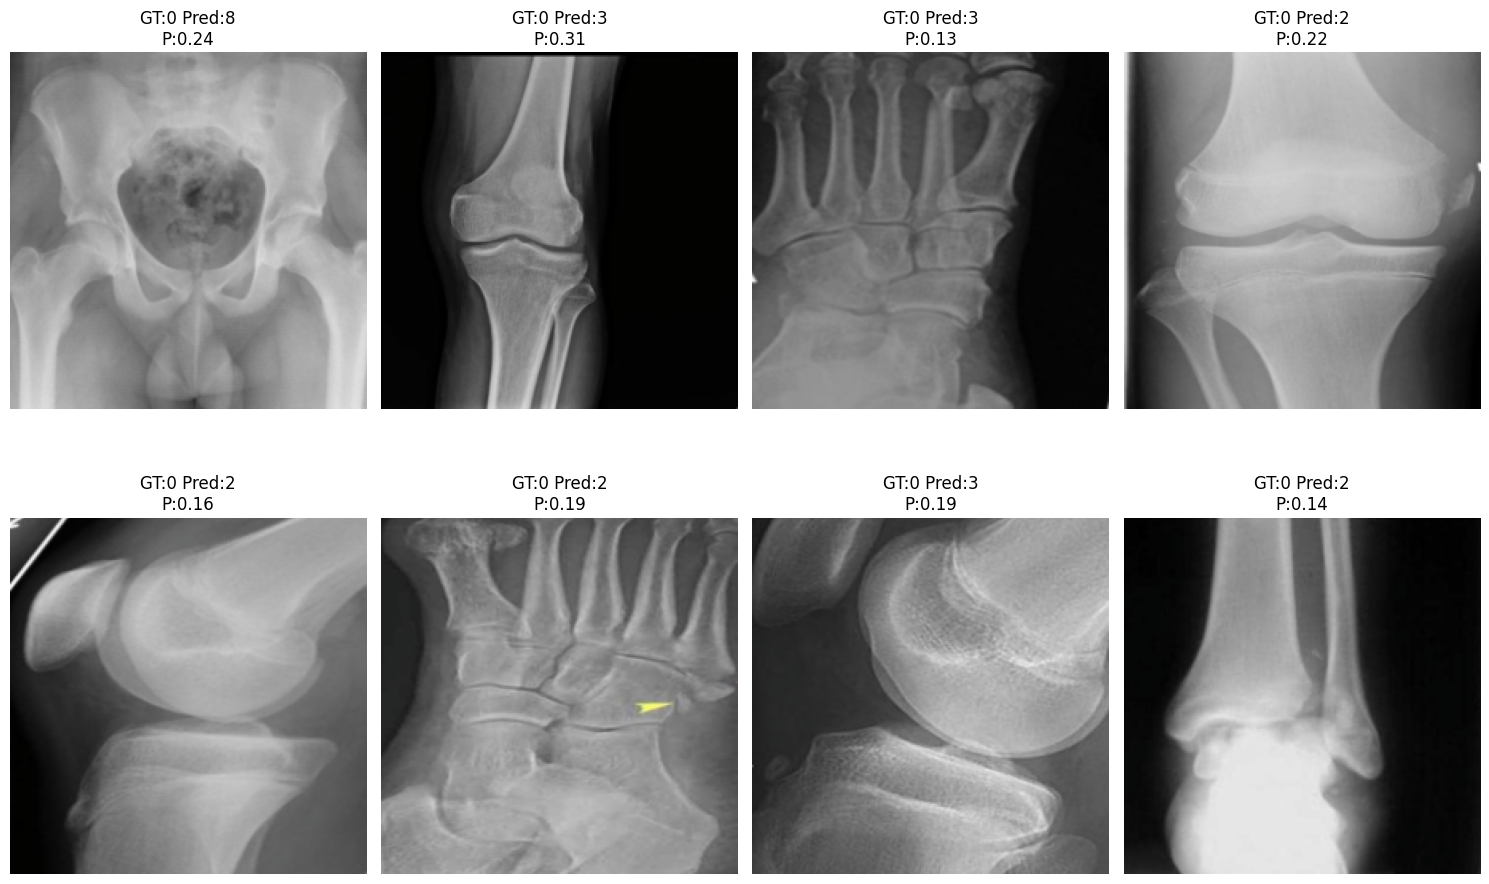

In [17]:
visualize_predictions(model, test_loader, device)

# (8) Make Evaluation with confusion matrix 

In [18]:
def plot_confusion_matrix(model, data_loader, device, title, figsize=(10, 8)):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            predictions = torch.argmax(logits, dim=1)
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()

    num_classes = len(np.unique(all_labels))
    tick_marks = np.arange(num_classes)
    
    if class_names is not None:
        plt.xticks(tick_marks, class_names, rotation=45, ha='right')
        plt.yticks(tick_marks, class_names)
    else:
        plt.xticks(tick_marks, range(num_classes))
        plt.yticks(tick_marks, range(num_classes))
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    accuracy = np.sum(all_preds == all_labels) / len(all_labels)
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    return accuracy, cm

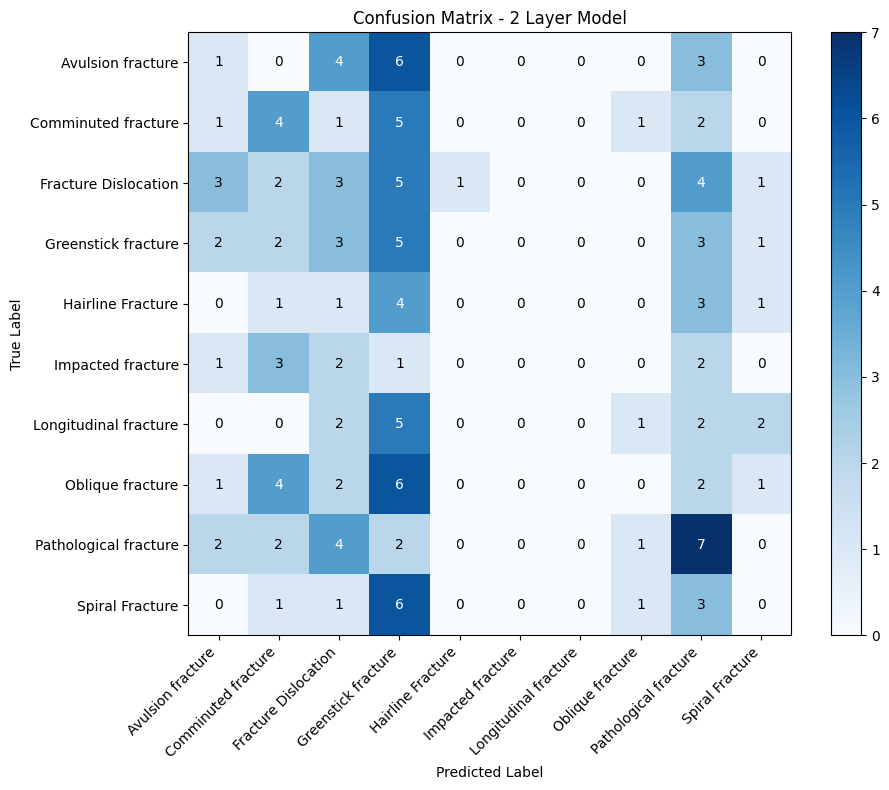

Test Accuracy: 0.1429 (14.29%)


In [19]:
# For first model (2 layers)
accuracy, cm = plot_confusion_matrix(
    model, 
    test_loader, 
    device, 
    title='Confusion Matrix - 2 Layer Model'
)

# (9) Instance of a new CNN 
Use the Sequential API it is faster 
- This cnn has tre hidden layers (conv2d -> proper activation -> max pool 2d)  one has 16 untis, the second has 32 units, and the third has 64
- Add a flatten layer 
- Classifier need 128 Linear unit proper activation and set dropdown at 0.5
- The last layer of the classifier how many units need?

Repeat from 5 to 8

In [20]:
params = {
    "number_of_output_classes":10, 
    "kernel_size":3, 
    "padding_size":1, 
    "pooling_size":2, 
    "input_channels":3,
    "dropout_probabilities":0.5,
    "dense_units":[128],
    "layers_list":[16,32,64] 
}
model = MyCNN(**params)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr= 1e-3,weight_decay=1e-4)

In [21]:
epochs = 50
best_val_acc = 0
val_acc = 0
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range (1, epochs + 1):
    train_loss, train_acc = train(model = model,loader=train_loader, criterion=criterion, optimizer=optimizer, device=device)
    print(f"Epoch #{epoch}/{epochs}, Train Loss = {train_loss:.4f}, Accuracy = {train_acc:.3f}")  
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_loss, val_acc = evaluation(model = model,loader=val_loader, criterion=criterion, device=device)
    print(f"Epoch #{epoch}/{epochs}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_acc:.3f}")  
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if (val_acc > best_val_acc):
        best_val_acc = val_acc
        torch.save(model.state_dict(),"Assignment1_best_model_3layer.pt")
print("Best Val Accuracy", best_val_acc)

Epoch #1/50, Train Loss = 2.4522, Accuracy = 0.119
Epoch #1/50, Val Loss = 2.2924, Val Accuracy = 0.111
Epoch #2/50, Train Loss = 2.2832, Accuracy = 0.142
Epoch #2/50, Val Loss = 2.2885, Val Accuracy = 0.096
Epoch #3/50, Train Loss = 2.2701, Accuracy = 0.149
Epoch #3/50, Val Loss = 2.2653, Val Accuracy = 0.121
Epoch #4/50, Train Loss = 2.2430, Accuracy = 0.176
Epoch #4/50, Val Loss = 2.2448, Val Accuracy = 0.131
Epoch #5/50, Train Loss = 2.2456, Accuracy = 0.155
Epoch #5/50, Val Loss = 2.2291, Val Accuracy = 0.162
Epoch #6/50, Train Loss = 2.2293, Accuracy = 0.176
Epoch #6/50, Val Loss = 2.2195, Val Accuracy = 0.167
Epoch #7/50, Train Loss = 2.2120, Accuracy = 0.182
Epoch #7/50, Val Loss = 2.2015, Val Accuracy = 0.207
Epoch #8/50, Train Loss = 2.2015, Accuracy = 0.195
Epoch #8/50, Val Loss = 2.2214, Val Accuracy = 0.152
Epoch #9/50, Train Loss = 2.1801, Accuracy = 0.224
Epoch #9/50, Val Loss = 2.1939, Val Accuracy = 0.227
Epoch #10/50, Train Loss = 2.1677, Accuracy = 0.190
Epoch #10/50

In [22]:
model.load_state_dict(torch.load("Assignment1_best_model_3layer.pt"))
print(f"Loaded best model with validation accuracy: {best_val_acc:.4f}")

Loaded best model with validation accuracy: 0.3283


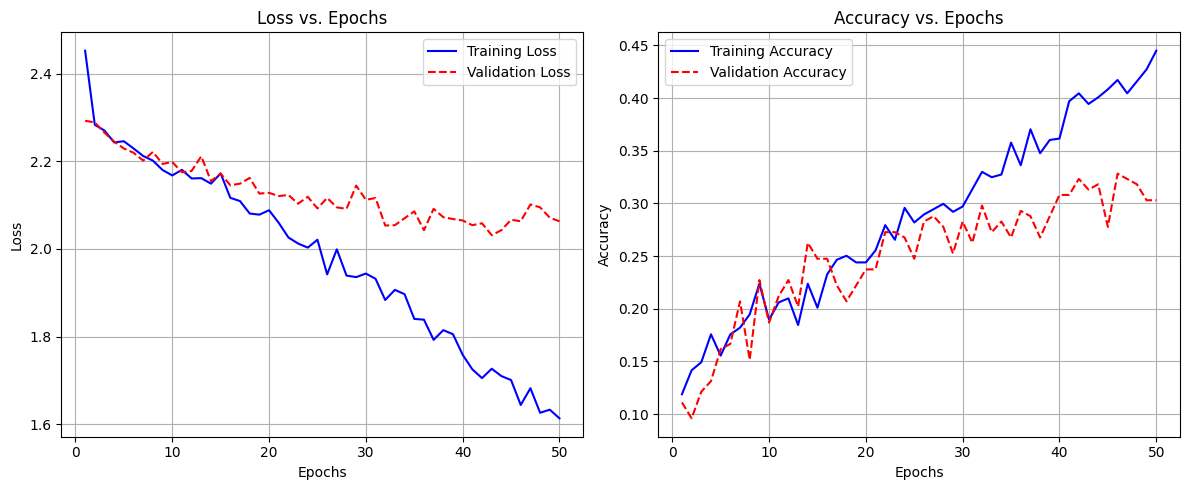

In [23]:
plt.figure(figsize=(12, 5))
# Plot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color='red', linestyle='--')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# Plot 2: Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_accs) + 1), val_accs, label='Validation Accuracy', color='red', linestyle='--')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

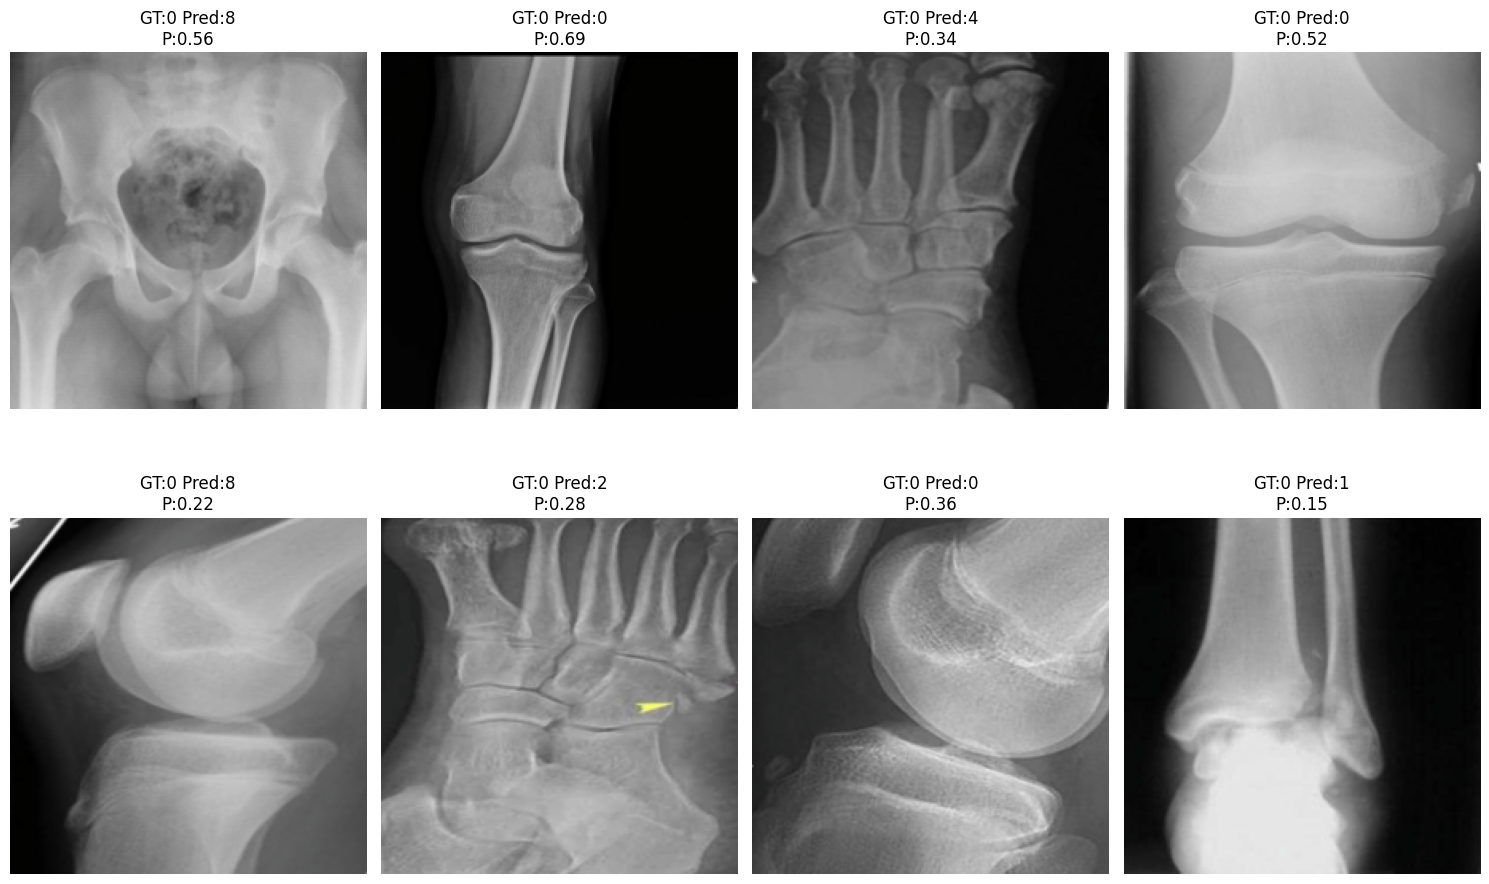

In [24]:
visualize_predictions(model, test_loader, device)

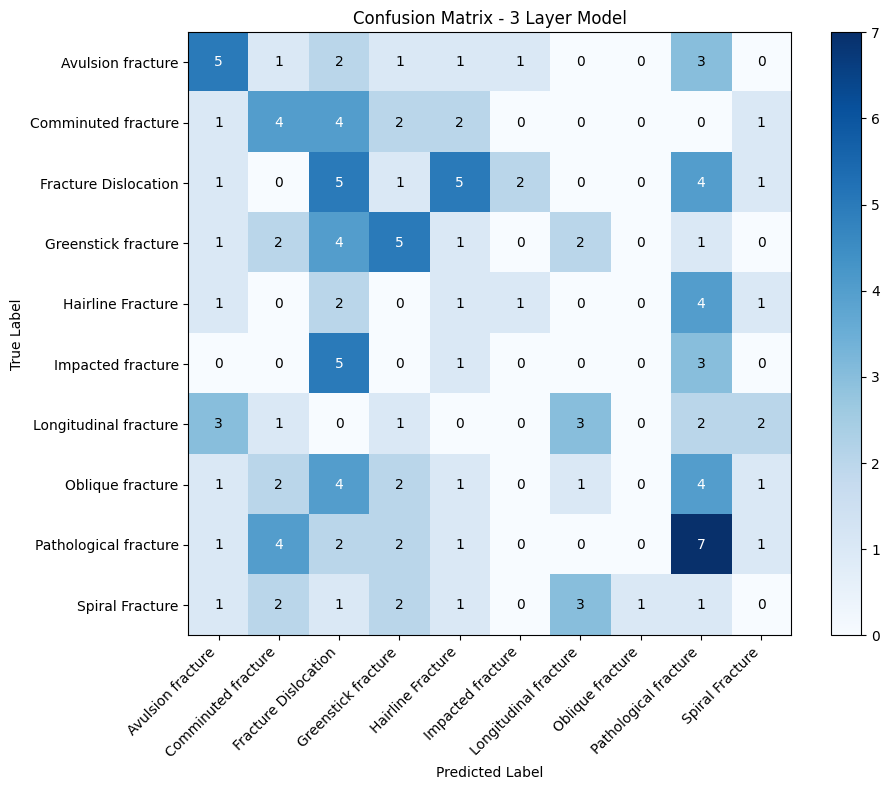

Test Accuracy: 0.2143 (21.43%)


In [25]:
# For second model (3 layers)
accuracy, cm = plot_confusion_matrix(
    model, 
    test_loader, 
    device, 
    title='Confusion Matrix - 3 Layer Model'
)

I wanted to play around with the model a bot more. here is that section


In [26]:
params = {
    "number_of_output_classes":10, 
    "kernel_size":3, 
    "padding_size":1, 
    "pooling_size":2, 
    "input_channels":3,
    "dropout_probabilities":0.1,
    "dense_units":[512],
    "layers_list":[16,32,64] 
}
model = MyCNN(**params)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr= 1e-3,weight_decay=1e-4)

In [27]:
epochs = 50
best_val_acc = 0
val_acc = 0
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range (1, epochs + 1):
    train_loss, train_acc = train(model = model,loader=train_loader, criterion=criterion, optimizer=optimizer, device=device)
    print(f"Epoch #{epoch}/{epochs}, Train Loss = {train_loss:.4f}, Accuracy = {train_acc:.3f}")  
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_loss, val_acc = evaluation(model = model,loader=val_loader, criterion=criterion, device=device)
    print(f"Epoch #{epoch}/{epochs}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_acc:.3f}")  
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if (val_acc > best_val_acc):
        best_val_acc = val_acc
        torch.save(model.state_dict(),"Assignment1_best_model_3layer.pt")
print("Best Val Accuracy", best_val_acc)

Epoch #1/50, Train Loss = 3.4438, Accuracy = 0.106
Epoch #1/50, Val Loss = 2.3065, Val Accuracy = 0.045
Epoch #2/50, Train Loss = 2.3019, Accuracy = 0.082
Epoch #2/50, Val Loss = 2.3052, Val Accuracy = 0.045
Epoch #3/50, Train Loss = 2.2997, Accuracy = 0.114
Epoch #3/50, Val Loss = 2.3039, Val Accuracy = 0.111
Epoch #4/50, Train Loss = 2.2955, Accuracy = 0.145
Epoch #4/50, Val Loss = 2.3016, Val Accuracy = 0.111
Epoch #5/50, Train Loss = 2.2873, Accuracy = 0.148
Epoch #5/50, Val Loss = 2.2991, Val Accuracy = 0.111
Epoch #6/50, Train Loss = 2.2743, Accuracy = 0.142
Epoch #6/50, Val Loss = 2.3002, Val Accuracy = 0.111
Epoch #7/50, Train Loss = 2.2699, Accuracy = 0.147
Epoch #7/50, Val Loss = 2.2984, Val Accuracy = 0.111
Epoch #8/50, Train Loss = 2.2606, Accuracy = 0.148
Epoch #8/50, Val Loss = 2.2870, Val Accuracy = 0.116
Epoch #9/50, Train Loss = 2.2477, Accuracy = 0.150
Epoch #9/50, Val Loss = 2.2805, Val Accuracy = 0.146
Epoch #10/50, Train Loss = 2.2377, Accuracy = 0.163
Epoch #10/50

FileNotFoundError: [Errno 2] No such file or directory: np.str_('BoneBreakClassification/Hairline Fracture/Train/xray-knees-avulsion-fracture-thumb-jpg.rf.245a6c847556ecac60f7b6fdf5054447.jpg')